# Chapter 13: New developments and challenges in text-to-image generation




Open in Colab:    
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/15p4RIPTgM-7bUGc8ITYQd0tsHcavmTpH?usp=sharing)


This chapter covers


* How state-of-the-art text-to-image generators work
* Challenges and concerns faced by text-to-image models
* Create a model to distinguish real images from deepfakes
* Prepare a large-scale dataset of real and fake images for fine-tuning
* Test the fine-tuned model on unseen images

By now, we have explored two ways of text-to-image generation, building models from scratch and unlocking the creative potential of modern AI. From early transformer-based generators to cutting-edge diffusion models, we’ve seen how machines can now turn simple prompts into breathtaking images based on text prompts.

Yet, with these advances come profound new challenges. As the quality and realism of generated images have skyrocketed, so too have the risks. Deepfakes, AI-generated images and videos designed to deceive, are now increasingly indistinguishable from real photographs. This presents not only technical hurdles, but also ethical, legal, and societal dilemmas. How do we ensure these powerful tools are used responsibly? Can we reliably detect AI-generated images, and what are the broader consequences when detection fails?

This chapter brings together the state of the art in text-to-image generation with the urgent need for practical safeguards and critical reflection. We begin by looking at how the latest models, including OpenAI’s DALL-E series, Google’s Imagen, and innovations like MidJourney, are pushing the boundaries of image generation. We then turn to the challenges facing the field, such as geometric inconsistency and the societal risks posed by misinformation, bias, and copyright concerns.

In direct response to these issues, we take a hands-on approach to defending against one of the most pressing threats: deepfakes. We show how a fine-tuned ResNet-50 can be used to distinguish real images from those generated by AI. By using deep-learning skills you’ve learned so far, this chapter closes the loop: we not only generate images, but also critically evaluate and defend against the risks these models pose.

As you work through this chapter, you’ll gain a dual perspective: both the excitement of new creative possibilities and the responsibility to anticipate and address the challenges that follow. This holistic view is essential for anyone hoping to innovate and safeguard the future of generative AI.

# 1. State-of-the-art text-to-image generators
# 2. Challenges and concerns
# 3. A blueprint to fine-tune ResNet-50 

In [1]:
!pip install kagglehub

## 3.3	Use ResNet-50 to classify images

In [2]:
import torchvision.models as models

weights = models.ResNet50_Weights.DEFAULT 
model = models.resnet50(weights=weights)    #A 
model.eval()    #B
print(model)    #C 
#A Initiate ResNet-50 with pretrained weights 
#B Set the model to evaluation mode for inference
#C Print out the model structure 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
from PIL import Image
import torch 
# download the image fish.png from the book's GitHub page
img = Image.open('files/fish.png').convert('RGB')    #A
preprocess = models.ResNet50_Weights.DEFAULT.transforms()
input_tensor = preprocess(img)    #B
input_batch = input_tensor.unsqueeze(0)    #C
print(f"the shape of the input image is {input_batch.shape}")
device="cuda" if torch.cuda.is_available() else "cpu"
input_batch = input_batch.to(device)
model.to(device)    #D
#A Read the sample image 
#B Transform the image into a PyTorch tensor with the desired size
#C Create a mini-batch as expected by ResNet-50
#D Move the input and model to GPU if available

the shape of the input image is torch.Size([1, 3, 224, 224])


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
# answer to exercise 13.1
img2 = Image.open('files/deer.png').convert('RGB')    
input_tensor2 = preprocess(img2)    
input_batch2 = input_tensor2.unsqueeze(0)    
print(f"the shape of the input image is {input_batch2.shape}")
input_batch2 = input_batch2.to(device)

the shape of the input image is torch.Size([1, 3, 224, 224])


In [5]:
from torch.nn.functional import softmax

with torch.no_grad(): 
    output = model(input_batch)    #A
probabilities = softmax(output[0],
         dim=0)    #B
predicted_class_idx = torch.argmax(probabilities).item()    #C
highest_prob = torch.max(probabilities).item()    #D
print("the predicted class is", predicted_class_idx)
print("the highest probability is", highest_prob)
#A Make a prediction on the sample image
#B Convert logits to probabilities
#C Obtain the class index with the highest probability
#D Obtain the highest probability

the predicted class is 1
the highest probability is 0.1901196837425232


In [6]:
labels = models.ResNet50_Weights.DEFAULT.meta['categories']
print(labels)    #A
print("object name is:", labels[predicted_class_idx])    #B
#A Print out the 1000 object names
#B Print out the name of the object with index 1

['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondback', 

In [7]:
# answer to exercise 13.2
with torch.no_grad(): 
    output2 = model(input_batch2)   
probabilities2 = softmax(output2[0],dim=0)   
predicted_class_idx2 = torch.argmax(probabilities2).item()    
highest_prob2 = torch.max(probabilities2).item()    
print("the predicted class is", predicted_class_idx2)
print("the highest probability is", highest_prob2)
print("object name is:", labels[predicted_class_idx2])    

the predicted class is 352
the highest probability is 0.45385193824768066
object name is: impala


In [8]:
probs=[]
indexes=[]
images=["bird","dog","bunny","fish"]
for img in images:    
    img = Image.open(f"files/{img}.png").convert('RGB')
    input_tensor = preprocess(img)
    input_batch = input_tensor.unsqueeze(0).to('cuda') 
    with torch.no_grad(): 
        output = model(input_batch)    #A
    probabilities = softmax(output[0],dim=0)
    idx=torch.argmax(probabilities).item()    #B
    indexes.append(idx)
    prob=torch.max(probabilities).item()    #C
    probs.append(prob)
#A Make predictions on the four images
#B Obtain the class indexes
#C Obtain the highest probabilities

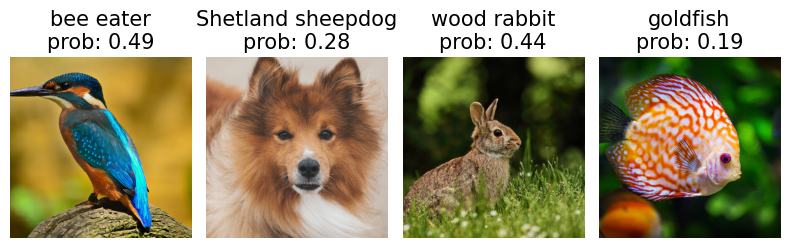

In [9]:
from torchvision import transforms
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5),dpi=100)
for i in range(4):    
    plt.subplot(1,4,i+1)
    img=Image.open(f"files/{images[i]}.png")
    img=transforms.ToTensor()(img)
    plt.imshow(img.permute(1,2,0))    #A
    pred=labels[indexes[i]]
    msg=f"{pred}\nprob: {probs[i]:.2f}"
    plt.title(msg,fontsize=15)    #B    
    plt.axis('off')
plt.tight_layout()
plt.show()
#A Display the four images
#B Display the predictions and the associated probabilities

# 4	Fine-tune ResNet-50 to detect fake images

## 4.1	Download and preprocess real and fake face images

In [10]:
import kagglehub

path = kagglehub.dataset_download(
    "xhlulu/140k-real-and-fake-faces")    #A

print("Path to dataset files:", path)    #B
train_dir=rf"{path}/real_vs_fake/real-vs-fake/train"
val_dir=rf"{path}/real_vs_fake/real-vs-fake/valid"
test_dir=rf"{path}/real_vs_fake/real-vs-fake/test"    #C
#A Download the dataset from Kaggle
#B Print out the local path to dataset files
#C Define the paths to the train, validation, and test subsets

Path to dataset files: C:\Users\hlliu2\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2


There are 50000 images in C:\Users\hlliu2\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2/real_vs_fake/real-vs-fake/train\fake.
There are 50000 images in C:\Users\hlliu2\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2/real_vs_fake/real-vs-fake/train\real.
There are 10000 images in C:\Users\hlliu2\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2/real_vs_fake/real-vs-fake/valid\fake.
There are 10000 images in C:\Users\hlliu2\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2/real_vs_fake/real-vs-fake/valid\real.
There are 10000 images in C:\Users\hlliu2\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2/real_vs_fake/real-vs-fake/test\fake.
There are 10000 images in C:\Users\hlliu2\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2/real_vs_fake/real-vs-fake/test\real.


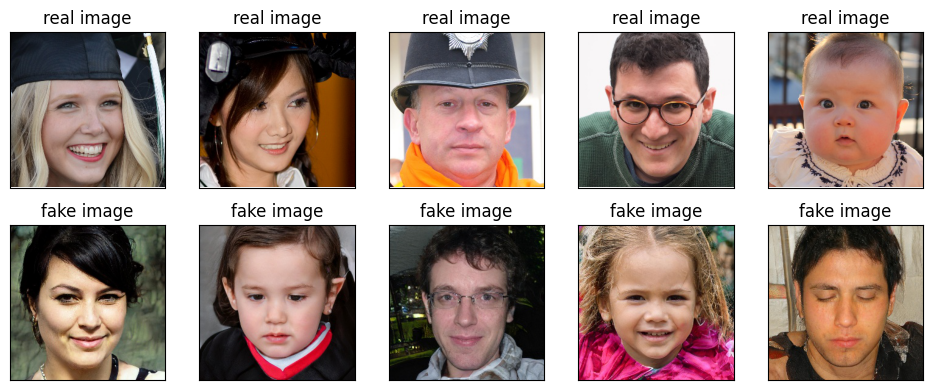

In [11]:
import os
import glob
import matplotlib.pyplot as plt
import PIL
def count_images(folder):
    for path, name, files in os.walk(folder):
        if len(files)>0:
            print(f"There are {len(files)} images in {path}.")
count_images(train_dir)
count_images(val_dir)
count_images(test_dir)    #A

imgs=glob.glob(f'{train_dir}/real/*.jpg')[66:66+5]+\
    glob.glob(f'{train_dir}/fake/*.jpg')[88:88+5]    #B

plt.figure(figsize=(10,4),dpi=100)
for i in range(10):    #C
    ax = plt.subplot(2,5, i + 1)
    img=PIL.Image.open(imgs[i])
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    if i<5:
        plt.title("real image")
    else:
        plt.title("fake image")
    plt.tight_layout()
plt.show()
#A Count the number of images in train, validation, and test subsets
#B Select five real images and five fake images 
#C Display the ten images in a 2x5 grid

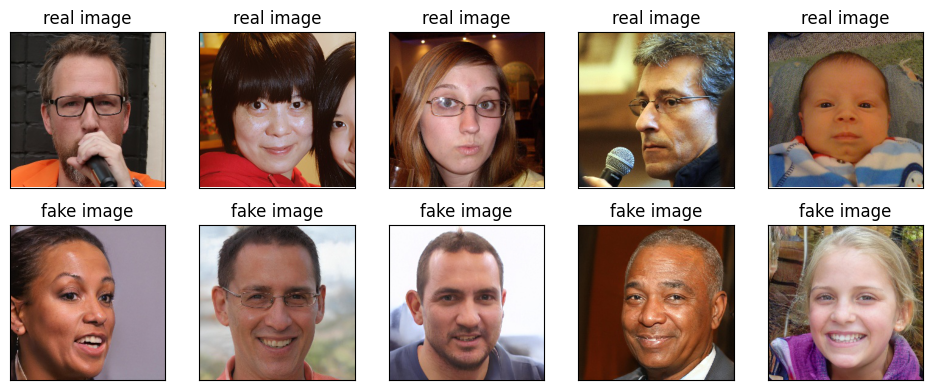

In [12]:
# exercise 13.3
imgs2=glob.glob(f'{val_dir}/real/*.jpg')[:5]+\
    glob.glob(f'{val_dir}/fake/*.jpg')[-5:]    

plt.figure(figsize=(10,4),dpi=100)
for i in range(10):    #C
    ax = plt.subplot(2,5, i + 1)
    img=PIL.Image.open(imgs2[i])
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    if i<5:
        plt.title("real image")
    else:
        plt.title("fake image")
    plt.tight_layout()
plt.show()

In [13]:
from torchvision import datasets, models
import torch

torch.manual_seed(42)
preprocess = models.ResNet50_Weights.DEFAULT.transforms()

train_data = datasets.ImageFolder(
    root=train_dir, 
    transform=preprocess, 
    target_transform=None)    #A
val_data = datasets.ImageFolder(
    root=val_dir, 
    transform=preprocess, 
    target_transform=None)    #B
test_data = datasets.ImageFolder(
    root=test_dir,
    transform=preprocess)    #C
#A Process images in the train subset
#B Process images in the validation subset
#C Process images in the test subset 

In [14]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32, 
                              shuffle=True)    #A 
val_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             shuffle=False) 
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             shuffle=True)    #B 
#A Put training data into batches of 32 observations
#B Do the same for validation and test subsets


## 4.2	Fine-tune ResNet-50


In [15]:
for param in model.parameters():
    param.requires_grad = False    #A

model.fc= torch.nn.Sequential(
    torch.nn.Linear(2048,1000),
    torch.nn.ReLU(),
    torch.nn.Linear(1000,500),
    torch.nn.Dropout(),
    torch.nn.Linear(in_features=500,
                    out_features=2,
                    bias=True)).to(device)    #B

num_trainable=sum([p.numel() for p in model.parameters() 
                     if p.requires_grad])
print(f"Number of trainable parameters: {num_trainable}")
non_trainable=sum([p.numel() for p in model.parameters() 
                     if not p.requires_grad])
print(f"Number of untrainable parameters: {non_trainable}")    #C
#A Freeze parameters in ResNet-50
#B Replace the output head so that there are two output channels
#C Count the number of parameters

Number of trainable parameters: 2550502
Number of untrainable parameters: 23508032


In [16]:
from tqdm import tqdm

def train_epoch(model,dataloader,loss_fn,optimizer):    #A
    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(tqdm(dataloader)):    #B
        X, y = X.to(device), y.to(device)
        y_pred = model(X)    #C
        loss = loss_fn(y_pred, y)    #D
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    #E
    return train_loss/len(dataloader)
#A Define the train_epoch() function
#B Iterate through all batches in the training dataset
#C Make predictions using the model 
#D Calculate the loss by comparing predictions with the ground truth
#E Backpropagate to minimize the loss


In [17]:
def val_epoch(model,dataloader,loss_fn):    #A
    model.eval()
    val_loss=0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):    #B
            X, y = X.to(device), y.to(device)
            pred_logits = model(X)
            loss = loss_fn(pred_logits, y)    
            val_loss += loss.item()
    return val_loss/len(dataloader)    #C
#A Define the val_epoch() function
#B Iterate through all batches in the validation dataset
#C Return the average loss in the epoch


In [18]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)


In [19]:
class EarlyStop:
    def __init__(self, patience=3):
        self.patience = patience
        self.steps = 0
        self.min_loss = float('inf')
    def stop(self, val_loss):
        if val_loss < self.min_loss:    #A
            self.min_loss = val_loss
            self.steps = 0
        elif val_loss >= self.min_loss:    #B
            self.steps += 1
        if self.steps >= self.patience:    #C
            return True
        else:
            return False
stopper=EarlyStop()    #D
#A If the validation loss is smaller than the previously achieved minimum, keep training
#B If the loss in the validation set is larger than the minimum, add 1 to the counter
#C If the performance doesn’t improve in three consecutive epochs, stop training
#D Instantiate the EarlyStop() class


In [20]:
for i in range(100):    #A
    trainloss=train_epoch(model,train_dataloader,
        loss_fn,optimizer)    #B
    valloss=val_epoch(model,val_dataloader,loss_fn)    #C
    print(f'epoch {i},trainloss={trainloss},valloss={valloss}')
    if stopper.stop(valloss)==True:    #D
        break
#A Fine-tune the model for a maximum of 100 epochs
#B Calcuate the training loss using the train_epoch() function
#C Calcuate the validation loss using the val_epoch() function
#D Stop training if the performance stops improving in the validation set


## 4.3	Detect deep fakes using the fine-tuned ResNet-50

In [21]:
import requests, os

url=("https://github.com/khanaabidabdal/"
     "Ai-Image-Classifier-Real-Vs-Fake-Faces/"
     "raw/main/RealityCheck.pth")    #A

file="files/RealityCheck.pth"    #B

if not os.path.exists(file):    #C
    print("downloading fine-tuned weights")
    fb=requests.get(url)
    with open(file,"wb") as f:
        f.write(fb.content) 
else:
    print("weights have already been downloaded")
model.load_state_dict(torch.load(file,    #D
			map_location=device)) 
#A URL to download the fine-tuned weights
#B Where to save the weights locally
#C Download the fine-tuned weights, if not already
#D Load the fine-tuned weights to the model


weights have already been downloaded


<All keys matched successfully>

In [22]:
torch.manual_seed(42)
imgs, ys = next(iter(test_dataloader))


In [23]:
with torch.inference_mode():
    X, y = imgs.to(device), ys.to(device)
    logits = model(X)
    preds = logits.argmax(dim=1)


In [24]:
print(ys)
print(preds)
print(ys==preds.cpu())

tensor([0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 1, 1, 0])
tensor([0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 0, 1, 0], device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True, False,
         True,  True])


In [25]:
# exercise 13.4
torch.manual_seed(0)
imgs2, ys2 = next(iter(test_dataloader))
with torch.inference_mode():
    X2, y2 = imgs2.to(device), ys2.to(device)
    logits2 = model(X2)
    preds2 = logits2.argmax(dim=1)
print(ys2)
print(preds2)
print(ys2==preds2.cpu())

tensor([1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
        0, 1, 1, 0, 1, 0, 0, 0])
tensor([1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
        0, 1, 1, 0, 1, 0, 0, 0], device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True])


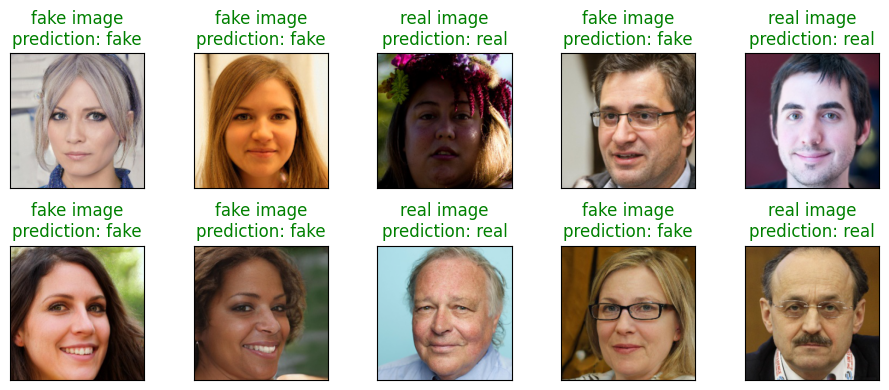

In [26]:
import torchvision.transforms as T

T1=T.Compose([
T.Normalize([0, 0, 0],
            [1/0.229, 1/0.224, 1/0.225])]) 

T2=T.Compose([
T.Normalize([-0.485, -0.456, -0.406],
            [1,1,1])]) 

plt.figure(figsize=(10,4),dpi=100)
for i in range(10):
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(T2(T1(imgs[i])).permute(1,2,0))
    plt.xticks([])
    plt.yticks([])
    if preds[i]==0 and ys[i]==0:
        plt.title("fake image\nprediction: fake",color="green")
    elif preds[i]==1 and ys[i]==0:
        plt.title("fake image\nprediction: real",color="red")   
    elif preds[i]==0 and ys[i]==1:
        plt.title("real image\nprediction: fake",color="red")           
    elif preds[i]==1 and ys[i]==1:
        plt.title("real image\nprediction: real",color="green")   
    plt.tight_layout()
plt.show()

In [27]:
model.eval()
test_acc = 0
with torch.inference_mode():
    for batch, (X, y) in enumerate(test_dataloader):
        X, y = X.to(device), y.to(device)
        test_pred_logits = model(X)
        test_pred_labels = test_pred_logits.argmax(dim=1)
        test_acc += ((test_pred_labels == y).sum(
            ).item()/len(test_pred_labels))
test_acc = test_acc / len(test_dataloader)
print(f"the prediction accuracy is {test_acc:.4f}")

the prediction accuracy is 0.9361
